🔵 Difference
- You try to find if there are any differences between group (healthy vs non-healthy)

🔵 Relationship
- You try to find some relationship between two variables (image feature and clinical data)
#
- Continuous variable: NUMBERS
- Ordinal numbers: ordered (Stage, good/better/best, ...)
- Nominal: Colors, Gender,...
#
- Parametric tests -> Data has normal distribution
- Outliers -> use non-parametric tests
#
🔵 Paired/Unpaired tests
- Unpaired tests -> two groups are independent (one with medicaments and another without)

In [8]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

🔵 Load all csv

In [49]:
# df = pd.read_csv(r"D:\DP\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df = pd.read_csv(r"D:\DP\CSV\merged_konv_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")

# df = pd.read_csv(r"D:\DP\ALL\m_001\CaSupp_25_radiomics_lesions_features.csv")

df = df.drop(columns=["patient"])
# df = df.drop(columns=["vertebra_name"])

🔵 Correlation of every feature with one selected feature

In [50]:
# Assuming n_lesions is the first column now
target = "original_shape_VoxelVolume"

correlations = []
for col in df.columns:
    if col != target:
        r, p = pearsonr(df[target], df[col])
        correlations.append({"Feature": col, "r": r, "p_value": p})

corr_df = pd.DataFrame(correlations)

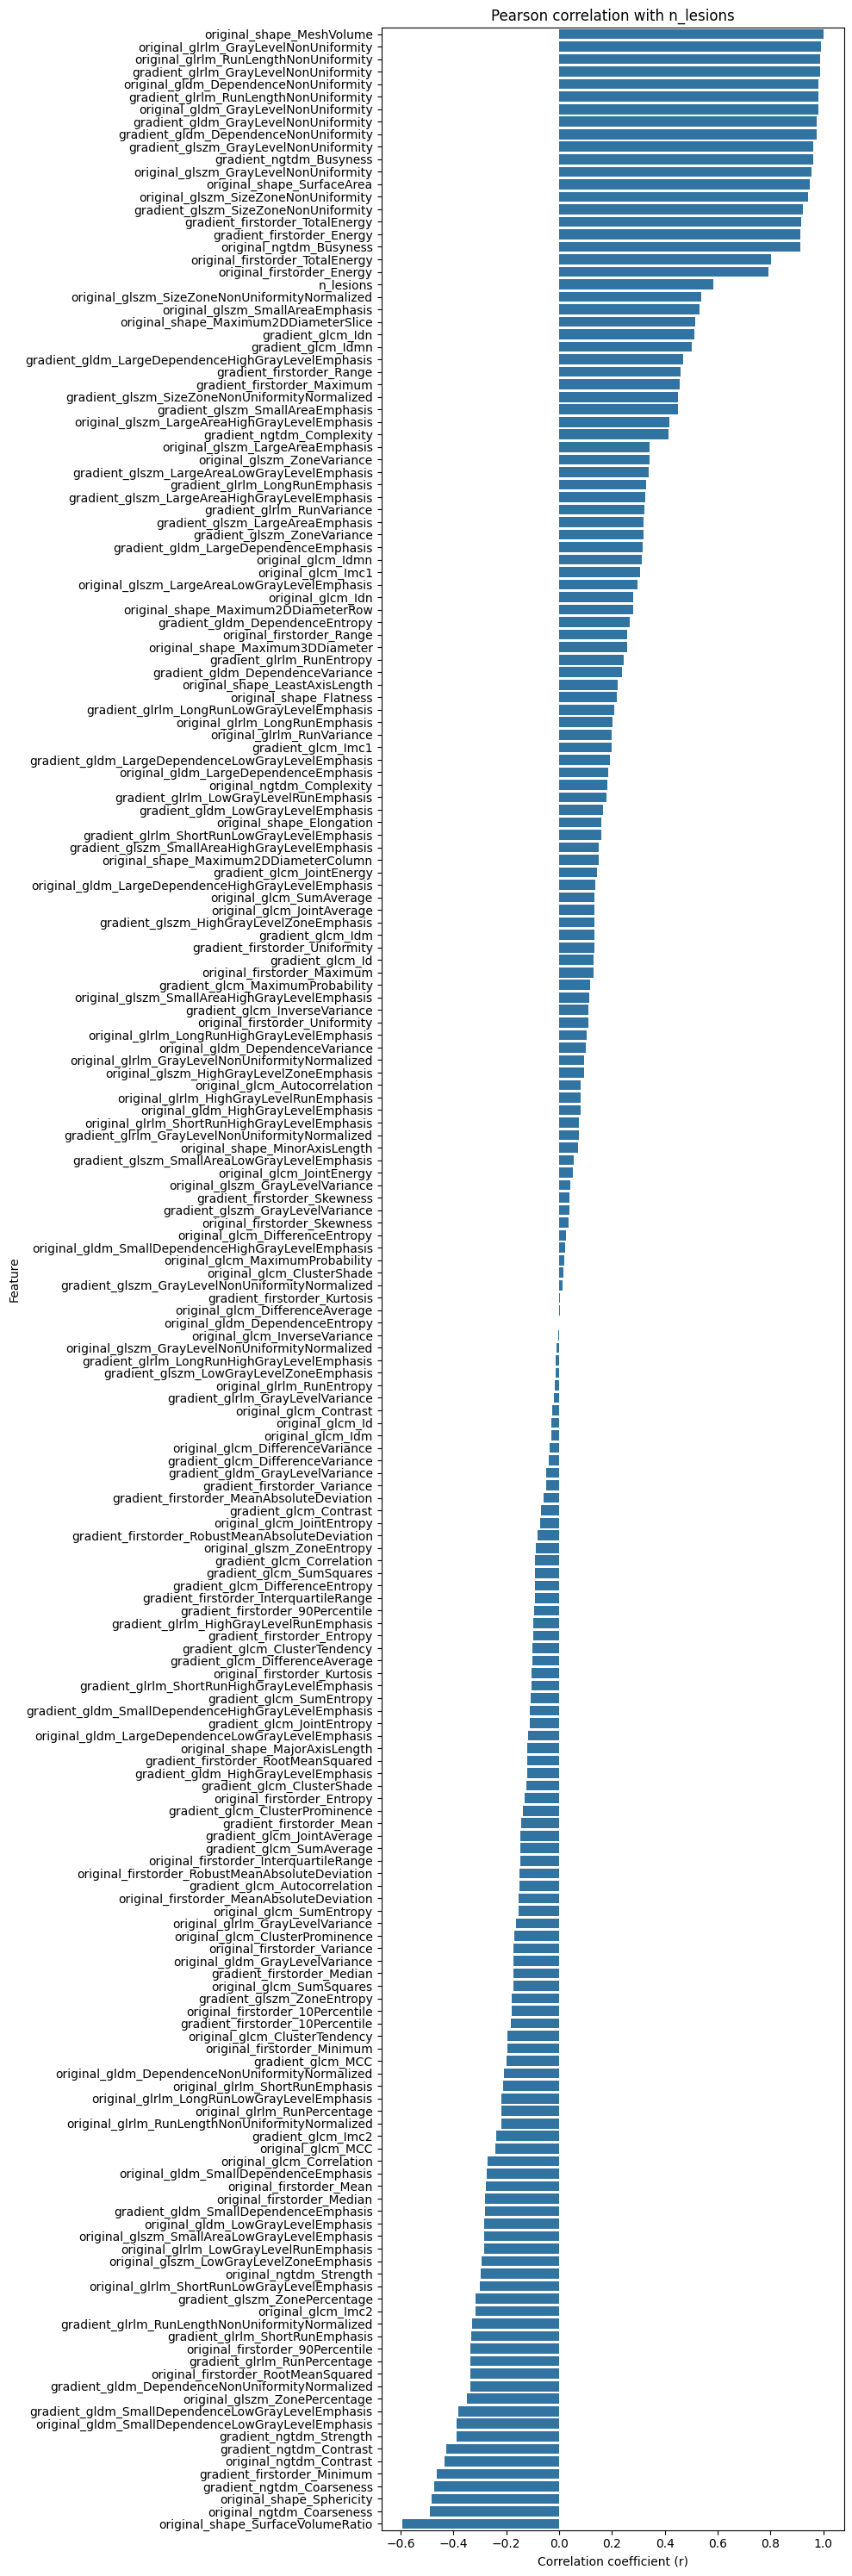

In [51]:
plt.figure(figsize=(10, 30))
sns.barplot(x="r", y="Feature", data=corr_df.sort_values("r", ascending=False))
plt.title("Pearson correlation with n_lesions")
plt.xlabel("Correlation coefficient (r)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()